In [15]:
import pandas as pd
import numpy as np

In [16]:
np.random.seed(42)

In [17]:
price = np.linspace(10,50,100)

# print(price)

competitor_price = price/2 + np.linspace(20,40,100) + np.random.randint(50,100,100)

is_promotion = np.random.binomial(1,0.3,100)

demand = 1000/price + 1000/competitor_price + 100*is_promotion + np.random.randint(100,300,100)

# print(competitor_price)

fake_data = pd.DataFrame({'demand':demand,
                          'price': price,
                          'competitor_price':competitor_price,
                          'is_promotion': is_promotion})


# print(demand)
print(fake_data)

        demand      price  competitor_price  is_promotion
0   394.849558  10.000000        113.000000             0
1   368.787307  10.404040        103.404040             0
2   349.658220  10.808081         89.808081             0
3   286.648559  11.212121        118.212121             0
4   392.046367  11.616162         83.616162             0
..         ...        ...               ...           ...
95  254.518348  48.383838        127.383838             1
96  146.834517  48.787879        157.787879             0
97  158.085729  49.191919        114.191919             0
98  223.378150  49.595960        138.595960             0
99  255.264463  50.000000        121.000000             1

[100 rows x 4 columns]


In [18]:
# 1000/773

# Linear version for clean OLS
demand_linear = -10*price + 5*competitor_price + 100*is_promotion + np.random.randint(100,300,100)
fake_data['demand_linear'] = demand_linear

In [19]:
import statsmodels.api as sm

# Use demand_linear first — cleaner for understanding OLS
X = fake_data[['price', 'competitor_price', 'is_promotion']]
X = sm.add_constant(X)  # adds the intercept term β0
y = fake_data['demand_linear']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          demand_linear   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     97.54
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           4.88e-29
Time:                        23:45:53   Log-Likelihood:                -549.37
No. Observations:                 100   AIC:                             1107.
Df Residuals:                      96   BIC:                             1117.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              203.9792     40.389  

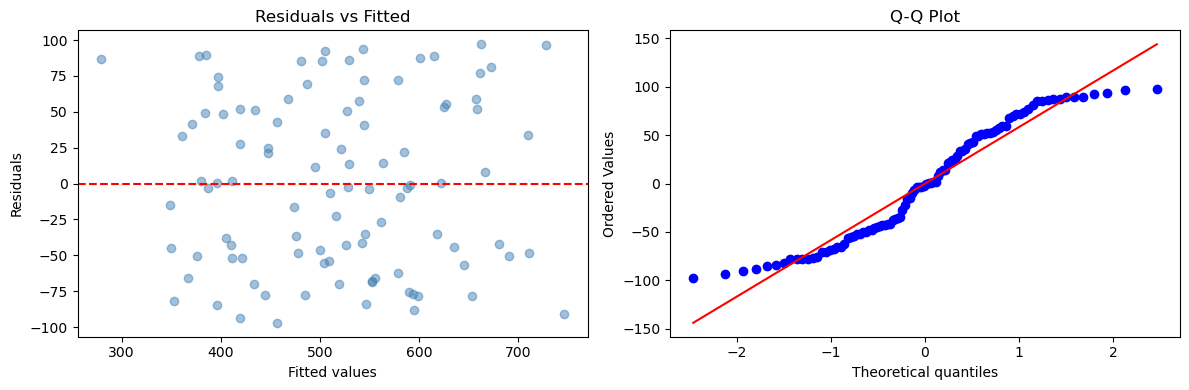

In [20]:
import matplotlib.pyplot as plt

fitted_values = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs fitted
axes[0].scatter(fitted_values, residuals, alpha=0.5, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# Q-Q plot for normality
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()


In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = fake_data[['price', 'competitor_price', 'is_promotion']]

vif_data = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) 
            for i in range(X_vif.shape[1])]
})

print(vif_data)

            feature        VIF
0             price  11.958780
1  competitor_price  12.579164
2      is_promotion   1.295451


In [26]:
X_reduced = fake_data[['price', 'is_promotion']]
X_reduced = sm.add_constant(X_reduced)
model_reduced = sm.OLS(y, X_reduced).fit()
print(model_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:          demand_linear   R-squared:                       0.390
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     30.98
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           3.95e-11
Time:                        23:52:19   Log-Likelihood:                -594.59
No. Observations:                 100   AIC:                             1195.
Df Residuals:                      97   BIC:                             1203.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          639.2311     26.585     24.045   

In [27]:
fake_data['price_ratio'] = fake_data['price'] / fake_data['competitor_price']

In [28]:
X_ratio = fake_data[['price_ratio', 'is_promotion']]
X_ratio = sm.add_constant(X_ratio)
model_ratio = sm.OLS(y, X_ratio).fit()
print(model_ratio.summary())

                            OLS Regression Results                            
Dep. Variable:          demand_linear   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.597
Method:                 Least Squares   F-statistic:                     74.40
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           2.60e-20
Time:                        23:53:09   Log-Likelihood:                -572.79
No. Observations:                 100   AIC:                             1152.
Df Residuals:                      97   BIC:                             1159.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          739.3002     25.144     29.403   